In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#spettro
def E(N):
    w0 = 1.0
    w1 = 1.1
    g2 = w0*w1
    Ep = 0.5*(w0*(2*N + 1) + (4*g2*(N+1) + (w0-w1)**2)**0.5)
    Em = 0.5*(w0*(2*N + 1) - (4*g2*(N+1) + (w0-w1)**2)**0.5)
    return np.array([Ep, Em])

N = np.linspace(0, 10, 100, endpoint=True)
energies = E(N)

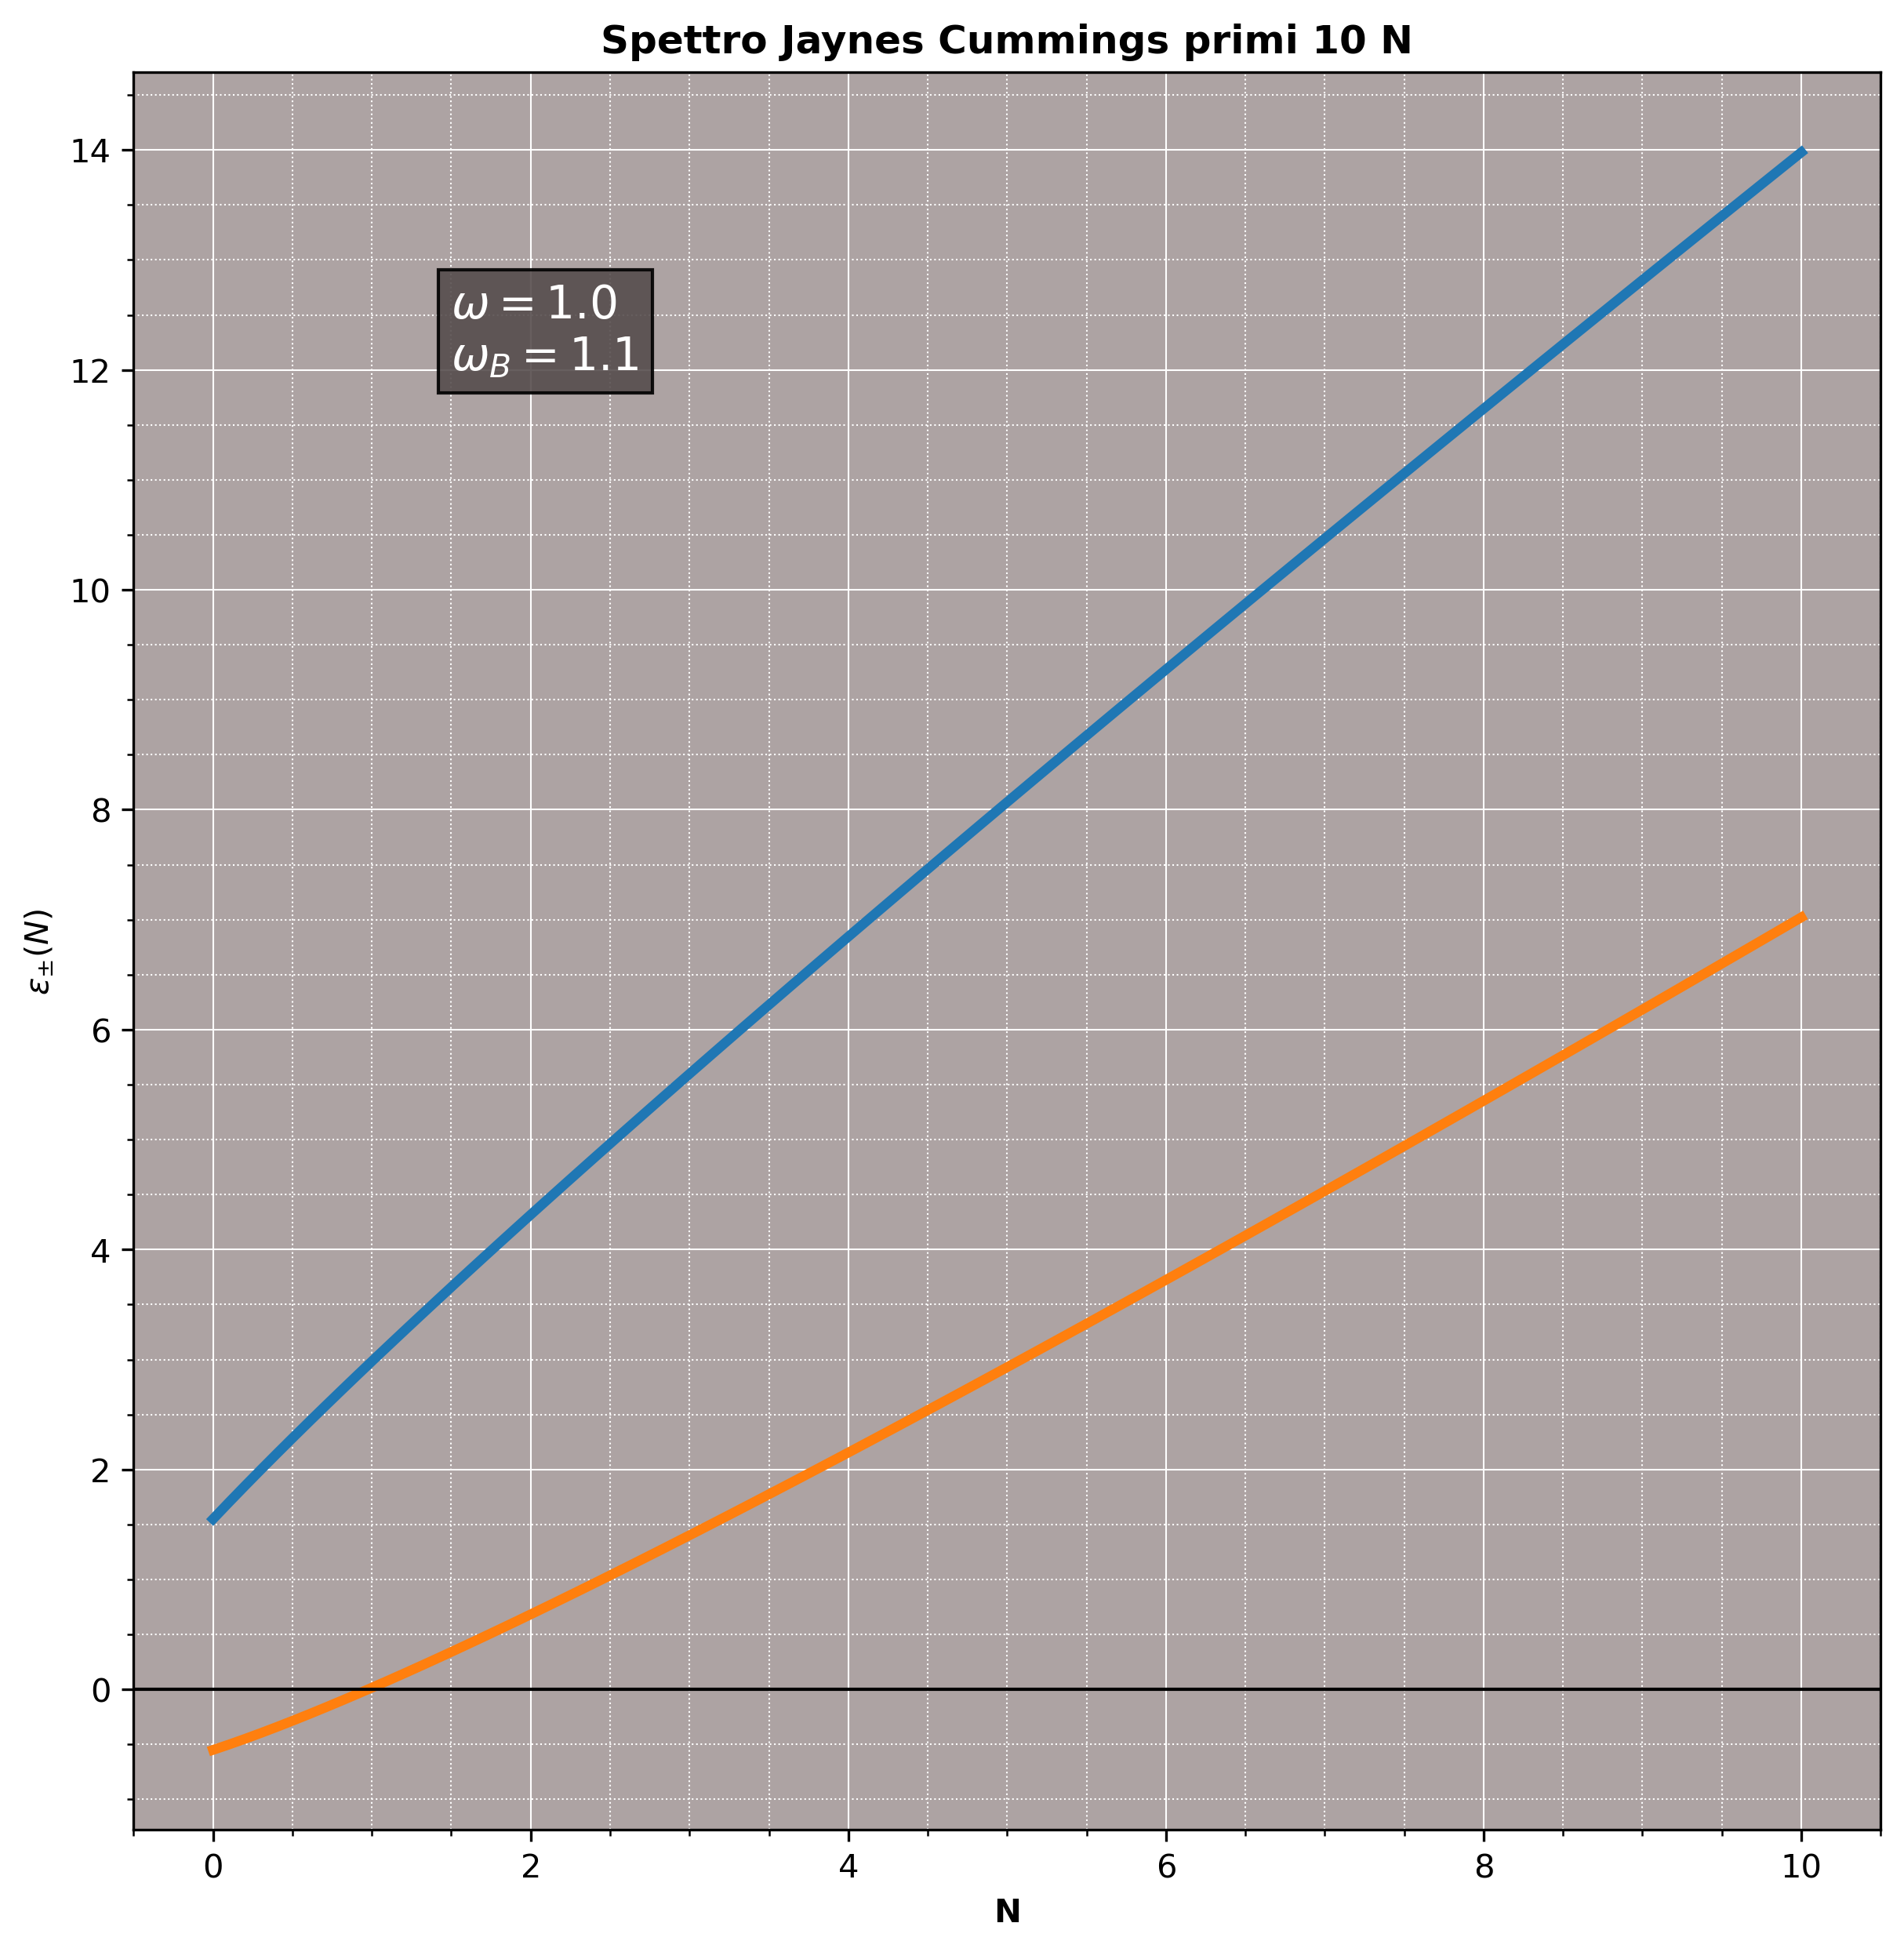

In [3]:
plt.figure(figsize=(8,8), dpi = 300)
plt.plot(N, energies[0], linewidth=3)
plt.plot(N, energies[1], linewidth = 3)
plt.minorticks_on()
plt.axhline(0, color='black', linewidth=1)
text = (
   f"$\\omega=1.0$ \n"
   f"$\\omega_B=1.1$"
)

light_gray = (1/255)*np.array([211, 211, 211])

plt.text(1.5, 12.0, text, fontsize=14, bbox=dict(facecolor= "#564D4D", alpha=0.9), color="white", fontweight="bold")

plt.grid(which='major', linestyle='-', linewidth=0.5, color='w')
plt.grid(which='minor', linestyle=':', linewidth=0.5, color='w')
plt.tight_layout()
plt.gca().set_facecolor('#ADA3A3')
plt.title("Spettro Jaynes Cummings primi 10 N", fontweight="bold")
plt.xlabel("N", fontweight="bold")
plt.ylabel(r"$\epsilon_{\pm}(N)$", fontweight="bold")
plt.grid(True, zorder = 0)
plt.savefig("spettro_jaynes_cummings.png", dpi=300, bbox_inches='tight')
plt.show()

In [4]:
#simulazioni
#calcoliamo prima il cutoff
gammaa = 140
gamma = 10
w0 = 1.1
w = 1.0
g = np.sqrt(w*w0)
cutoff = int((gammaa - gamma)/gamma)

In [5]:
#costruiamo la matrice passo passo
#fissiamo il cutoff n
n = cutoff + 1 #c'è +1 per essere consistente con la mia notazione
empty = np.zeros((8*n+1, 8*n+1), dtype = float)
#dobbiamo ora inizializzarlo
#NON SERVE MA NON LO CANCELLO PERCHè POTREBBE SERVIRE IN FUTURO
vect = np.zeros((8*n+1, 1), dtype = float)
vect[8*(n-1)+0, 0] = 0.5
vect[8*(n-1)+1, 0] = 0.02
vect[8*(n-1)+2, 0] = 0.08
vect[8*(n-1)+3, 0] = 0.5
vect[8*(n-1)+4, 0] = 0
vect[8*(n-1)+5, 0] = 0.04
vect[8*(n-1)+6, 0] = -0.08
vect[8*(n-1)+7, 0] = 0
#ora riempiamola con i vari termini
for i in range(n-1, -1, -1):
    if i == n-1:
        #reale 00
        empty[8*i, 8*i] = -gamma 
        empty[8*i, 8*i+5] = 2*g*np.sqrt(i)
        empty[8*i, 8*i+6] = -2*g*np.sqrt(i)
        #reale 01
        empty[8*i+1, 8*i+1] = -(gamma/2)*(2*i - 1) - (gammaa/2)
        empty[8*i+1, 8*i+5] = - (w-w0)
        #reale 10
        empty[8*i+2, 8*i+2] = -(gamma/2)*(2*i - 1) - (gammaa/2)
        empty[8*i+2, 8*i+6] = - (w-w0)
        #reale 11
        empty[8*i+3, 8*i+5] = - 2*g*np.sqrt(i)
        empty[8*i+3, 8*i+6] = 2*g*np.sqrt(i)
        empty[8*i+3, 8*i+3] = - (gamma*(i-1) + gammaa)
        #immaginario 00
        #non lo tocchiamo, è nullo
        #immaginario 01
        empty[8*i+5, 8*i+5] = -(gamma/2)*(2*i - 1) - (gammaa/2)
        empty[8*i+5, 8*i+1] = (w-w0)
        empty[8*i+5, 8*i] = g*np.sqrt(i)
        empty[8*i+5, 8*i+3] = -g*np.sqrt(i)
        #immaginario 10
        empty[8*i+6, 8*i+6] = (gamma/2)*(2*i - 1) + (gammaa/2)
        empty[8*i+6, 8*i+2] = -(w-w0)
        empty[8*i+6, 8*i] = -g*np.sqrt(i)
        empty[8*i+6, 8*i+3] = g*np.sqrt(i)
        #immaginario 11
        #non lo tocchiamo, è nullo
    elif i<1:
        empty[8*i, 8*(i+1)] = gamma
        empty[8*i, 8*(i+1)+3] = gammaa
    else:
        #reale 00
        empty[8*i, 8*(i+1)] = gamma*(i+1)
        empty[8*i, 8*i] = -gamma
        empty[8*i, 8*(i+1)+3] = gammaa 
        empty[8*i, 8*i+5] = 2*g*np.sqrt(i)
        empty[8*i, 8*i+6] = -2*g*np.sqrt(i)
        #reale 01
        empty[8*i+1, 8*(i+1)+1] = np.sqrt(i*(i+1))
        empty[8*i+1, 8*i+1] = -(gamma/2)*(2*i - 1) - (gammaa/2)
        empty[8*i+1, 8*i+5] = - (w-w0)
        #reale 10
        empty[8*i+2, 8*(i+1)+2] = np.sqrt(i*(i+1))
        empty[8*i+2, 8*i+2] = -(gamma/2)*(2*i - 1) - (gammaa/2)
        empty[8*i+2, 8*i+6] = - (w-w0)
        #reale 11
        empty[8*i+3, 8*i+5] = - 2*g*np.sqrt(i)
        empty[8*i+3, 8*i+6] = 2*g*np.sqrt(i)
        empty[8*i+3, 8*i+3] = - (gamma*(i-1) + gammaa)
        empty[8*i+3, 8*(i+1)+3] = gamma*(i)
        #immaginario 00
        #non lo tocchiamo, è nullo
        #immaginario 01
        empty[8*i+5, 8*(i+1)+5] = np.sqrt(i*(i+1))
        empty[8*i+5, 8*i+5] = -(gamma/2)*(2*i - 1) - (gammaa/2)
        empty[8*i+5, 8*i+1] = (w-w0)
        empty[8*i+5, 8*i] = g*np.sqrt(i)
        empty[8*i+5, 8*i+3] = -g*np.sqrt(i)
        #immaginario 10
        empty[8*i+6, 8*(i+1)+6] = -np.sqrt(i*(i+1))
        empty[8*i+6, 8*i+6] = (gamma/2)*(2*i - 1) + (gammaa/2)
        empty[8*i+6, 8*i+2] = -(w-w0)
        empty[8*i+6, 8*i] = -g*np.sqrt(i)
        empty[8*i+6, 8*i+3] = g*np.sqrt(i)
        #immaginario 11
        #non lo tocchiamo, è nullo

In [6]:
#verifichiamo che funziona
empty[30]

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        , -1.81659021,
        0.        ,  0.1       ,  1.81659021,  0.        ,  0.        ,
       95.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        , -3.46410162,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.  

In [7]:
from scipy.linalg import null_space

In [8]:
#troviamo le soluzioni stazionarie
A = np.array(empty)
soluzione_stazionaria = null_space(A)
print(soluzione_stazionaria.shape)

(113, 35)


In [9]:
#verifichiamo che abbia funzionato
soluzione_stazionaria[:,5]

array([ 0.00000000e+00,  1.56402142e-01,  3.12392480e-01, -4.17408648e-02,
        1.57106257e-01, -3.58095049e-01, -1.05923270e-02,  3.63837577e-01,
       -2.22044605e-16, -8.38630380e-17,  5.04696111e-17,  0.00000000e+00,
       -5.13694211e-02, -5.55111512e-17, -1.66533454e-16, -8.55920192e-02,
       -6.66133815e-16,  2.09251019e-17,  4.78133158e-17,  5.55111512e-17,
        4.27245731e-01,  3.88578059e-16,  4.16333634e-17,  2.04114123e-01,
        1.17961196e-16, -1.90745043e-16, -2.70738835e-16, -2.08166817e-17,
       -5.30436095e-02, -6.93889390e-17, -2.01227923e-16, -3.78130758e-01,
       -4.42354486e-17,  9.86454570e-17,  1.52762392e-16,  5.55111512e-17,
        1.04690187e-01, -6.24500451e-17,  1.73472348e-17,  5.21141664e-02,
        6.93889390e-17,  1.60326396e-17, -1.59692392e-16, -5.55111512e-17,
       -1.40163639e-02,  1.38777878e-16,  1.24900090e-16, -1.14559306e-01,
        5.55111512e-17,  2.19313771e-17, -6.91917921e-17, -2.77555756e-17,
        1.45146639e-01,  

In [10]:
#scriviamoci le soluzioni come x + iy, e tronchiamole a 3 cifre decimali, tutto quel che è sotto è rumore, perchè sì
total_solutions = []
for k in range(len(soluzione_stazionaria[0])):
    v = soluzione_stazionaria[:,k]
    sol = []
    sol.append(v[0])
    for i in range(1,8*n+1,8):
        for j in range(4):
            if abs(v[i+j]) > 10e-3:
                real = v[i+j]
            else:
                real = 0
            if abs(v[i+j+4]) > 10e-3:    
                imag = v[i+j+4]
            else:
                imag = 0
            sol.append(real + 1j * imag)
    sol = np.array(sol)
    sol = np.round(sol, 3)
    total_solutions.append(sol)
total_solutions = np.array(total_solutions)

In [11]:
np.shape(total_solutions)

(35, 57)

In [12]:
for obj in total_solutions:
    print(obj)

[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
[ 0.   +0.j     0.107+0.112j -0.13 +0.246j  0.022+0.181j  0.444+0.j
  0.   +0.j     0.   +0.j     0.   -0.077j  0.345+0.j     0.   +0.j
  0.   +0.j     0.   -0.083j -0.214+0.j     0.   +0.j     0.   +0.j
  0.   +0.j     0.089+0.j     0.   +0.j     0.   +0.j     0.   +0.103j
  0.101+0.j     0.   +0.j     0.   +0.j     0.   +0.035j -0.482+0.j
  0.   +0.j     0.   +0.j     0.   -0.249j -0.024+0.j     0.   +0.j
  0.   +0.j     0.   -0.057j  0.269+0.j     0.   +0.j     0.   +0.j
  0.   +0.03j  -0.061+0.j     0.   +0.j     0.   +0.j     0.   -0.257j
 -0.138+0.j     0.   +0.j     0.   +0.j     

In [13]:
#ora dobbiamo scartare le soluzioni non fisiche.
#controlliamo prima che la traccia sia =1 entro una certa tolleranza, 41*10e-3, ho propagato "ad occhio" l'errore di tolleranza
#poi controlliamo che le popolazioni siano positive e reali
#poi controlliamo che le coerenze siano complesse coniugate
physical_solutions = []

for i in range(len(total_solutions[:,0])):
    populations = np.array([total_solutions[i, j] + total_solutions[i, j+1] for j in range(0, len(total_solutions[0,:]), 4) if j+1 < len(total_solutions[0,:])])
    traccia = abs(np.sum(populations))
    pops = np.array([[total_solutions[i, j], total_solutions[i,j+1]] for j in range(0, len(total_solutions[0,:]), 4) if j+1 < len(total_solutions[0,:])])
    coherences_boolean = np.array([np.isclose(total_solutions[i, j], np.conj(total_solutions[i,j+1]), atol = 10e-3) for j in range(2, len(total_solutions[0,:]), 4) if j+1 < len(total_solutions[0,:])])
    if np.isclose(traccia, 1, atol = 41*10e-2) == True and np.all((pops.real >= 0) & (abs(pops.imag) <= 10e-1)) == True and np.all(coherences_boolean == True) == True:
        physical_solutions.append(total_solutions[i,:])

physical_solutions = np.array(physical_solutions)

In [14]:
np.shape(physical_solutions)

(3, 57)

In [16]:
#può dare soluzioni spurie sull'ultimo elemento perchè il numero di oggetti è dispari e fa i compionamenti prendendo 2 numeri
#per volta quindi l'ultimo non lo vede, vabbe possiamo levarlo a mano
physical_solutions

array([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.